## 1. Install packages
Run once. Restart kernel after installation.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')  # prevent OpenMP duplicate-runtime segfault (torch+MKL/numba)

# ── Kernel sanity check ───────────────────────────────────────────────────────
# This notebook must run on the "Python (thesis)" kernel (conda env `thesis`, Py 3.11).
# `!conda activate` in a cell does NOT work — each ! line is a throwaway subshell.
# Select the kernel via the picker (top-right), not here.
import sys
print('Interpreter:', sys.executable)
print('Python     :', sys.version.split()[0])
assert 'envs\\thesis' in sys.executable or 'envs/thesis' in sys.executable, (
    'Wrong kernel! Select "Python (thesis)" in the kernel picker, then restart.')
print('OK — running on the thesis env.')

Interpreter: c:\Users\pruth\anaconda3\envs\thesis\python.exe
Python     : 3.11.15
OK — running on the thesis env.


In [2]:
# ── Install all dependencies ──────────────────────────────────────────────────
import subprocess, sys, shlex

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *shlex.split(pkg)])

pip('torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121')
pip('sentence-transformers>=2.7.0')
pip('bertopic>=0.16.0')
pip('umap-learn>=0.5.6')
pip('hdbscan>=0.8.33')
pip('transformers>=4.40.0')
pip('datasets>=2.19.0')
pip('setfit>=1.0.3')
pip('shap>=0.45.0')
pip('lime>=0.2.0.1')
pip('vaderSentiment')
pip('scikit-learn>=1.4.0')
pip('pandas>=2.0.0')
pip('numpy>=1.26.0')
pip('matplotlib>=3.8.0')
pip('seaborn>=0.13.0')
pip('plotly>=5.20.0')
pip('openpyxl>=3.1.0')
pip('wordcloud')
pip('accelerate>=0.27.0')
pip('scipy>=1.12.0')

KeyboardInterrupt: 

## 2. GPU verification and global config

In [3]:
import torch
import numpy as np
import os

# ── CUDA verification ─────────────────────────────────────────────────────────
print('='*55)
print(f'PyTorch version   : {torch.__version__}')
print(f'CUDA available    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU               : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total        : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'CUDA version      : {torch.version.cuda}')
print('='*55)

# ── RTX 4060 Laptop optimisations ────────────────────────────────────────────
# Ampere architecture supports TF32 and BF16 natively
torch.backends.cudnn.benchmark     = True   # auto-tune conv algorithms
torch.backends.cuda.matmul.allow_tf32 = True  # faster matmul on Ampere
torch.backends.cudnn.allow_tf32    = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16   # 8 GB VRAM → use FP16 for inference

print(f'\nUsing device: {DEVICE}')
print(f'Default dtype: {DTYPE}')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
import pathlib
DATA_DIR    = pathlib.Path('data')
OUTPUT_DIR  = pathlib.Path('outputs')
MODEL_DIR   = pathlib.Path('models')
for d in [DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(exist_ok=True)
print(f'\nDirectories ready: {DATA_DIR}, {OUTPUT_DIR}, {MODEL_DIR}')

PyTorch version   : 2.5.1+cu121
CUDA available    : True
GPU               : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM total        : 8.6 GB
CUDA version      : 12.1

Using device: cuda
Default dtype: torch.float16

Directories ready: data, outputs, models


## 3. Data loading
Set `USE_DEMO = False` and point `EXCEL_PATH` to your Qualtrics export when ready.

In [4]:
import pandas as pd

# Project-relative configuration. Override EXCEL_PATH before running if the source
# workbook is stored elsewhere; no user-specific absolute path is required.
USE_DEMO = False
PROJECT_ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name.lower() == 'code' else pathlib.Path.cwd()
EXCEL_PATH = PROJECT_ROOT / 'Dataset' / 'Decision-making_final set-3.xlsx'

DECISION_CODES = {
    'voluntary_informed': 0,
    'feeling_pressured': 1,
    'insufficient_info': 2,
    'too_much_info': 3,
    'no_consent': 4,
}
EXPERIENCE_CODES = {'positive': 0, 'negative': 1}

CODE_DEFINITIONS = {
    'voluntary_informed': ('The woman felt well informed about the risks, benefits and alternatives and made a genuinely voluntary, uncoerced decision about induction of labour'),
    'feeling_pressured': ('The woman felt pressured, bullied, threatened, scared, gaslit, or coerced into agreeing to induction of labour'),
    'insufficient_info': ('The woman did not receive enough information about the risks, benefits and alternatives to induction of labour to make an informed decision'),
    'too_much_info': ('The woman felt overwhelmed or made more anxious by too much negative information or horror stories about induction'),
    'no_consent': ("Induction or an induction procedure was performed without asking for or obtaining the woman's consent, or against her explicitly stated wishes"),
}
print(f'Input workbook: {EXCEL_PATH.resolve()}')
print('Code definitions loaded.')


Input workbook: C:\Users\pruth\OneDrive\Desktop\UL\Sem 3-Dissertation-Thesis\Dataset\Decision-making_final set-3.xlsx
Code definitions loaded.


In [5]:
# ── Demo dataset (drawn from screenshots and paper quotes) ────────────────────
DEMO_DECISION = [
    ('In my experience of the community midwifery team they didn\'t even bring up induction. '
     'Information was very thorough with risks, benefits and alternatives. '
     'I never felt pressured.', 'voluntary_informed'),
    ('In the domino scheme, you were educated on risk and benefits very well. '
     'I never felt pressured to have an induction. I really felt supported in '
     'waiting for spontaneous labour.', 'voluntary_informed'),
    ('I had 2 inductions and found them to be a very positive experience. '
     'I never felt pushed into the decision. My babies and I were kept safe at all times.',
     'voluntary_informed'),
    ('I knew a lot about inductions. I declined at 40+7 and waited until 41+6. '
     'I declined the gel and agreed to the hormonal pessary. I wanted to give nature a nudge.',
     'voluntary_informed'),
    ('Everything was explained to me and I was really well cared for by the consultant and the midwives. '
     'I was happy to go with the midwife suggestions.', 'voluntary_informed'),
    ('I was told we will bring you in for induction or we won\'t let you go past X date. '
     'This was stated as fact as if I had no choice. Most people consent because they don\'t '
     'know they can say no.', 'feeling_pressured'),
    ('I was forced into getting an induction. I was threatened and cajoled until I agreed. '
     'I had to fight for 42 hours not to have one. It was exhausting.', 'feeling_pressured'),
    ('My consultant asked me did I want my baby to die when I requested we delay the induction. '
     'Pure and utter fearmongering.', 'feeling_pressured'),
    ('The system wore me down. I think people can be informed but still not feel like they '
     'have agency. There is a lot of pressure and fearmongering.', 'feeling_pressured'),
    ('I begged them to leave me be. I felt enormous pressure from the doctor. She told me '
     'my baby would become stuck and they would break her collar bone.', 'feeling_pressured'),
    ('I wish someone had told me I could refuse the induction. Everyone told me I couldn\'t refuse. '
     'I was scare-mongered into it as a first time mum.', 'feeling_pressured'),
    ('Antenatal classes told me I always had an option but I was told on admission I didn\'t '
     'have an option and there was no alternative available.', 'feeling_pressured'),
    ('There is no consent. They are advertised as routine when they are the opposite. '
     'There is no informed consent, only veiled coercion. The risks are never discussed.',
     'feeling_pressured'),
    ('They are way too normalised. Women don\'t want to be an issue so just go with whatever '
     'the medical staff tell them.', 'feeling_pressured'),
    ('Information provided by the hospital was non-existent. Doctor rang the ward and booked '
     'me in for an induction without my consent. She told me I had to have one because it was '
     'bad for baby. No information about benefits or risks was discussed.', 'insufficient_info'),
    ('The risks were never discussed and the benefits were grossly exaggerated. '
     'The maternity is a conveyor belt. There is no person-centred care.', 'insufficient_info'),
    ('Oxytocin needs to be explained more. I didn\'t realise how much pain it would cause. '
     'In the end it didn\'t work after 12 hours and I was brought in for an emergency section.',
     'insufficient_info'),
    ('I feel my induction was completely unnecessary. I went through three days of '
     'psychological and physical pain. Nobody explained what had happened or why.',
     'insufficient_info'),
    ('I wasn\'t given informed consent about sweeps. I didn\'t know the risks like infection '
     'or premature rupture of membranes.', 'insufficient_info'),
    ('Women need to be informed exactly what happens with induction, what happens if it '
     'doesn\'t work, and explain the different stages. Myself and my partner had no clue.',
     'insufficient_info'),
    ('The risks of inductions are never explained. I never knew that prostaglandins carry a '
     'blood clot risk and with my history I should never have received them.', 'insufficient_info'),
    ('I feel the risks were not explained fully and even after I experienced hyperstimulation '
     'nobody explained to me what had happened or why.', 'insufficient_info'),
    ('I was not aware that many inductions end in emergency c-section.', 'insufficient_info'),
    ('I think there are lots of negative stories about inductions and it causes anxiety. '
     'While I had a positive experience I wish there were more positive stories.',
     'too_much_info'),
    ('Inductions are discussed in scary and negative terms. I think it should be highlighted '
     'you can be induced and still have a positive vaginal birth experience.', 'too_much_info'),
    ('I was so afraid going into it, my anxiety was so bad, but it ended up being okay.',
     'too_much_info'),
    ('I was informed I could have a vaginal examination at 39 weeks to see how things were '
     'progressing but my consultant did a sweep without asking if I wanted it.', 'no_consent'),
    ('I consented to induction. I thought I was only consenting to gel. I was in active labour '
     'when they started me on oxytocin but I was told it was just a drip.', 'no_consent'),
    ('I had clearly stated in my birth plan that I did not want my water broken and it was '
     'still done without my consent and without my partner present.', 'no_consent'),
    ('I was booked in for induction at one of my appointments. I was never asked if I wanted '
     'one. I believed I had to be induced because of having gestational diabetes.', 'no_consent'),
]

DEMO_EXPERIENCE = [
    ('It was a very positive experience overall.', 'positive'),
    ('I had a good experience with my induction on my second baby.', 'positive'),
    ('I\'ve had three inductions and been very happy with them all.', 'positive'),
    ('Not all inductions are bad. They get a really bad reputation. I\'m delighted I had one.',
     'positive'),
    ('I\'ve had two and they both have been very positive and quick.', 'positive'),
    ('I had a positive experience with all the staff.', 'positive'),
    ('I had an induction for each of my children for various reasons and I\'m grateful for the '
     'amazing medical care.', 'positive'),
    ('I was terrified about being induced but it ended up being quite positive although very long.',
     'positive'),
    ('They are long and painful. I had to beg for gas and air before I went to the labour ward '
     'even though contractions were every 90 seconds for hours and hours. Still wasn\'t dilated.',
     'negative'),
    ('Induction was pure hell. The contractions were so strong and quick and the midwife laughed '
     'at me and said I wouldn\'t be able to cope with labour.', 'negative'),
    ('It is a distressing experience. I found it painful and no one told me at any stage that '
     'the pain was due to the induction gels.', 'negative'),
    ('I was induced on my first. It was awful. I went from no pain to a lot of pain in seconds '
     'and felt completely out of control.', 'negative'),
    ('They definitely make me feel more panic and pain than spontaneous labour.', 'negative'),
    ('The induction process was awful. Pains came on so intense straight away and no break. '
     'I was scared.', 'negative'),
    ('I had a high temp and there was grade 3 meconium at birth. Baby spent 4 days in NICU. '
     'It was terrible.', 'negative'),
    ('The breaking of the waters was the most painful thing I have ever felt. It was more '
     'traumatic than the birth and I was not prepared for it at all.', 'negative'),
]

print(f'Demo decision-making responses: {len(DEMO_DECISION)}')
print(f'Demo experience responses: {len(DEMO_EXPERIENCE)}')

Demo decision-making responses: 30
Demo experience responses: 16


In [6]:
import re

def clean_text(text: str) -> str:
    """Preserve emotional register — light cleaning only."""
    if not isinstance(text, str):
        return ''
    text = text.strip()
    # Remove PDF watermark artefacts
    text = re.sub(r'\bPage\s+\d+\b', '', text, flags=re.IGNORECASE)
    # Normalise Unicode quotes
    text = text.replace('‘', "'").replace('’', "'")
    text = text.replace('“', '"').replace('”', '"')
    # Normalise whitespace
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def add_trace_ids(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    """Add stable, pseudonymous row identifiers for downstream traceability."""
    df = df.reset_index(drop=True).copy()
    df['source_row_id'] = [f'{split_name}_source_{i:04d}' for i in range(len(df))]
    df['response_id'] = [f'{split_name}_{i:04d}' for i in range(len(df))]
    return df


def build_dataframe(samples: list, code_map: dict, split_name: str) -> pd.DataFrame:
    df = pd.DataFrame(samples, columns=['response_text', 'code'])
    df['split']         = split_name
    df['label']         = df['code'].map(code_map)
    df['response_text'] = df['response_text'].apply(clean_text)
    df['word_count']    = df['response_text'].str.split().str.len()
    df['char_count']    = df['response_text'].str.len()
    return add_trace_ids(df, split_name)

# ── Real-data files (this study's annotated Excel exports) ────────────────────
# Decision-making: sheet 'Export' — integer 'Final codes' column (1..5, plus an
#   'other' bucket we drop) and the response text in the 3rd column.
# Experiences: one text column per file, NO header row (the first response would
#   otherwise be swallowed as the column name), one class per file.
DECISION_FILE    = 'Decision-making_final set-3.xlsx'
EXPERIENCE_FILES = {
    'positive': 'Positive experiences (1).xlsx',
    'negative': 'Negative experiences-2.xlsx',
}
# Annotator's 1-based 'Final codes' → our 0-based decision labels (order matches DECISION_CODES)
FINAL_CODE_TO_LABEL = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}

def load_real_data(data_dir) -> dict:
    """Load the three annotated Excel files (in data_dir) into decision / experience splits."""
    import pathlib
    data_dir = pathlib.Path(data_dir)
    inv_dec  = {v: k for k, v in DECISION_CODES.items()}

    # ---- Decision-making (5 codes) ----
    raw = pd.read_excel(data_dir / DECISION_FILE, sheet_name='Export')
    dm = pd.DataFrame({
        'response_text': raw.iloc[:, 2],                       # 3rd column holds the text
        'fc':            pd.to_numeric(raw['Final codes'], errors='coerce'),
        'source_row_id': [f'decision_source_{i:04d}' for i in raw.index],
    })
    dm = dm[dm['fc'].isin(FINAL_CODE_TO_LABEL)].copy()         # keep 1..5, drop 'other'/blank
    dm['label'] = dm['fc'].astype(int).map(FINAL_CODE_TO_LABEL)
    dm['code']  = dm['label'].map(inv_dec)
    dm['split'] = 'decision_making'

    # ---- Experiences (2 codes, one file per class, no header row) ----
    exp_parts = []
    for code_name, fname in EXPERIENCE_FILES.items():
        r = pd.read_excel(data_dir / fname, sheet_name=0, header=None)
        part = pd.DataFrame({'response_text': r[0]})
        part['source_row_id'] = [f'{code_name}_experience_source_{i:04d}' for i in r.index]
        part['code']  = code_name
        part['label'] = EXPERIENCE_CODES[code_name]
        part['split'] = 'experience'
        exp_parts.append(part)
    exp = pd.concat(exp_parts, ignore_index=True)

    # ---- Clean + finalise both splits ----
    out = []
    for df in (dm, exp):
        df['response_text'] = df['response_text'].apply(clean_text)
        df = df[df['response_text'].str.len() > 0]
        df['word_count'] = df['response_text'].str.split().str.len()
        df['char_count'] = df['response_text'].str.len()
        df = df[['source_row_id', 'response_text', 'code', 'split', 'label',
                 'word_count', 'char_count']].reset_index(drop=True)
        split_name = str(df['split'].iloc[0]) if len(df) else 'unknown'
        df['response_id'] = [f'{split_name}_{i:04d}' for i in range(len(df))]
        out.append(df[['response_id', 'source_row_id', 'response_text', 'code', 'split', 'label',
                       'word_count', 'char_count']])
    dm, exp = out
    return {'decision': dm, 'experience': exp,
            'full': pd.concat([dm, exp], ignore_index=True)}

# ── Load ──────────────────────────────────────────────────────────────────────
if USE_DEMO:
    dm_df  = build_dataframe(DEMO_DECISION,   DECISION_CODES,  'decision_making')
    exp_df = build_dataframe(DEMO_EXPERIENCE, EXPERIENCE_CODES, 'experience')
    data   = {'decision': dm_df, 'experience': exp_df,
               'full': pd.concat([dm_df, exp_df], ignore_index=True)}
    print('[DEMO MODE] Using hardcoded samples from paper.')
else:
    # EXCEL_PATH points at the decision file; the other two live in the same folder
    import pathlib
    DATASET_DIR = pathlib.Path(EXCEL_PATH).parent
    data = load_real_data(DATASET_DIR)
    print(f'[REAL DATA] Loaded from {DATASET_DIR} (3 annotated Excel files)')

dm_df  = data['decision']
exp_df = data['experience']

print(f'\nDecision-making subset: {len(dm_df)} rows')
print(f'Experience subset: {len(exp_df)} rows')
print('\nDecision code distribution:')
print(dm_df['code'].value_counts().to_string())
print('\nExperience code distribution:')
print(exp_df['code'].value_counts().to_string())

[REAL DATA] Loaded from c:\Users\pruth\OneDrive\Desktop\UL\Sem 3-Dissertation-Thesis\Dataset (3 annotated Excel files)

Decision-making subset: 278 rows
Experience subset: 207 rows

Decision code distribution:
code
insufficient_info     145
feeling_pressured      80
voluntary_informed     36
too_much_info           9
no_consent              8

Experience code distribution:
code
negative    149
positive     58


## 4. Exploratory Data Analysis

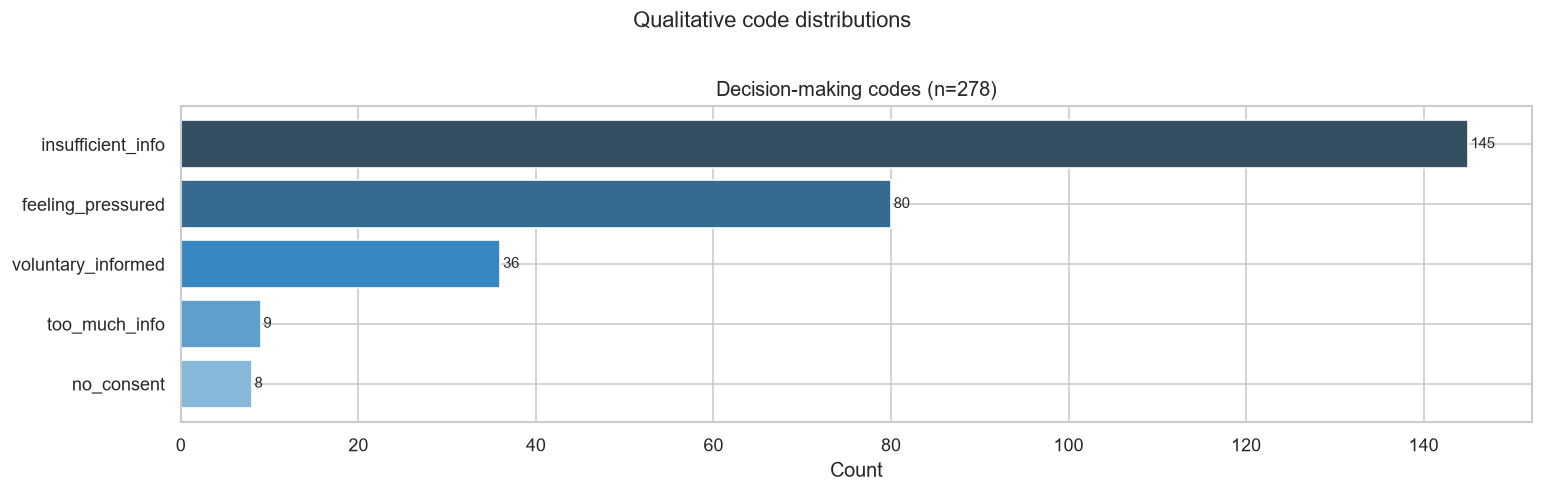

NOTE: Severe class imbalance — insufficient_info dominates. Macro F1 (not accuracy) is the primary metric.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Figure 1: Class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(13, 4))

# Decision codes
counts_dm = dm_df['code'].value_counts().sort_values()
colors_dm = sns.color_palette('Blues_d', len(counts_dm))
axes.barh(counts_dm.index, counts_dm.values, color=colors_dm)
axes.set_xlabel('Count')
axes.set_title('Decision-making codes (n={})'  .format(len(dm_df)))
for i, (idx, val) in enumerate(counts_dm.items()):
    axes.text(val + 0.3, i, str(val), va='center', fontsize=9)

# Experience codes
# counts_exp = exp_df['code'].value_counts()
# axes[1].pie(counts_exp.values, labels=counts_exp.index, autopct='%1.0f%%',
#             colors=sns.color_palette('Set2', 2), startangle=140)
# axes[1].set_title('Experience codes (n={})'.format(len(exp_df)))

plt.suptitle('Qualitative code distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_distribution.png', bbox_inches='tight')
plt.show()
print('NOTE: Severe class imbalance — insufficient_info dominates. '
      'Macro F1 (not accuracy) is the primary metric.')

C:\Users\pruth\AppData\Local\Temp\ipykernel_24480\2773615111.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dm_df, x='code', y='word_count', order=code_order,
C:\Users\pruth\AppData\Local\Temp\ipykernel_24480\2773615111.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels([c.replace('_', '\n') for c in code_order], fontsize=8)


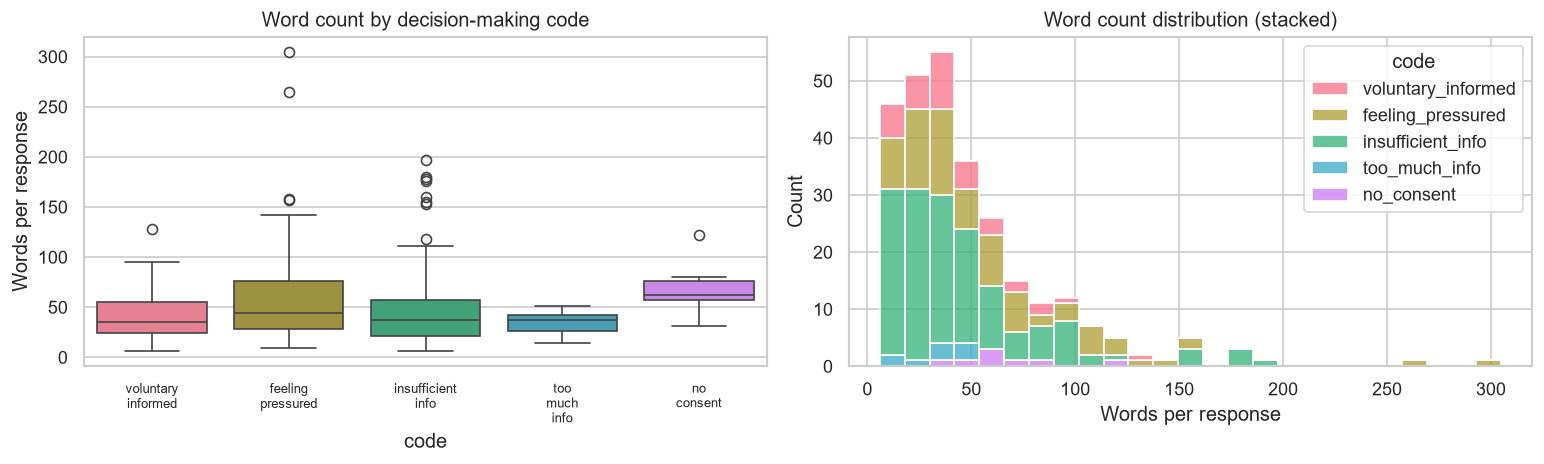


Median word counts by code:
                    median       mean  min  max
code                                           
feeling_pressured     44.0  60.987500    9  305
insufficient_info     37.0  46.517241    6  197
no_consent            62.5  67.750000   31  122
too_much_info         37.0  34.111111   14   51
voluntary_informed    35.5  41.861111    6  128


In [8]:
# ── Figure 2: Response length distributions by code ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

code_order = list(DECISION_CODES.keys())
palette = sns.color_palette('husl', len(code_order))

sns.boxplot(data=dm_df, x='code', y='word_count', order=code_order,
            palette=palette, ax=axes[0])
axes[0].set_xticklabels([c.replace('_', '\n') for c in code_order], fontsize=8)
axes[0].set_title('Word count by decision-making code')
axes[0].set_ylabel('Words per response')

sns.histplot(data=dm_df, x='word_count', hue='code', bins=25,
             multiple='stack', palette=palette, ax=axes[1])
axes[1].set_title('Word count distribution (stacked)')
axes[1].set_xlabel('Words per response')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_response_lengths.png', bbox_inches='tight')
plt.show()

print('\nMedian word counts by code:')
print(dm_df.groupby('code')['word_count'].agg(['median', 'mean', 'min', 'max']))

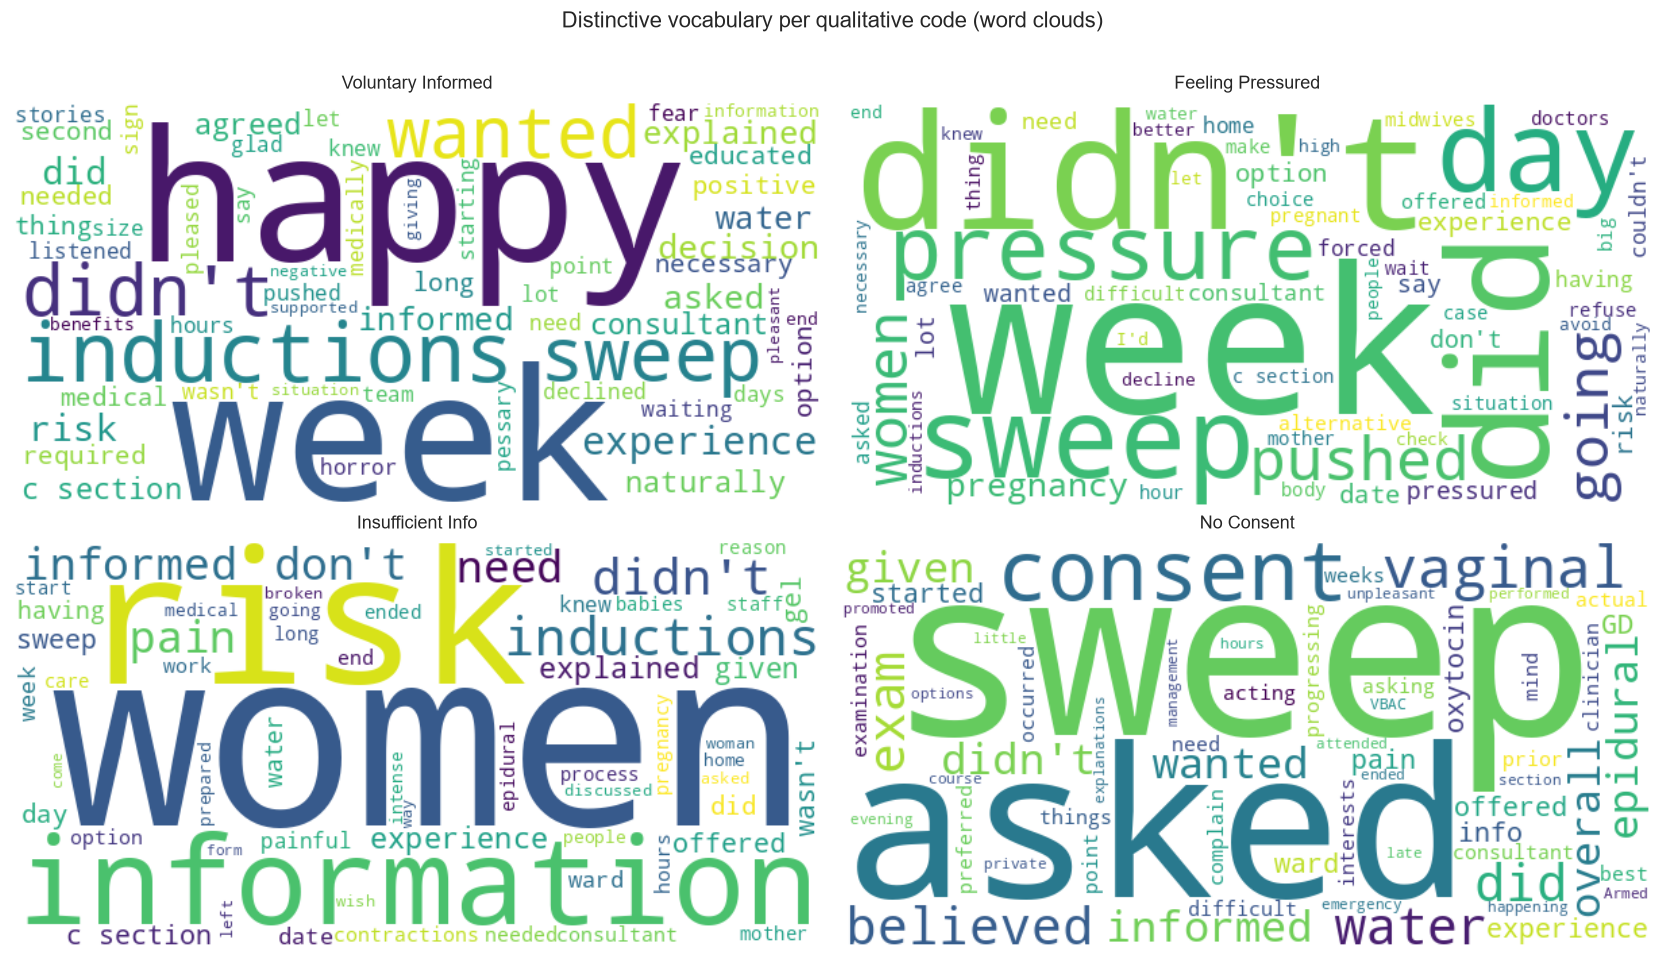

In [9]:
# ── Figure 3: Word clouds per decision-making code ────────────────────────────
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Domain stopwords to remove (frequent but uninformative for code separation)
DOMAIN_STOPS = {'induction', 'induced', 'baby', 'labour', 'birth', 'hospital',
                'midwife', 'doctor', 'felt', 'feel', 'told', 'said', 'think',
                'know', 'want', 'like', 'just', 'really', 'time', 'also', 'would',
                'one', 'go', 'went', 'get', 'got', 'had', 'have', 'was', 'were'}
ALL_STOPS = ENGLISH_STOP_WORDS | DOMAIN_STOPS

codes_to_plot = ['voluntary_informed', 'feeling_pressured',
                 'insufficient_info', 'no_consent']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, code in enumerate(codes_to_plot):
    subset_text = ' '.join(dm_df[dm_df['code'] == code]['response_text'].tolist())
    if len(subset_text) < 10:
        axes[i].set_title(f'{code} (insufficient data)')
        continue
    wc = WordCloud(
        width=600, height=300, background_color='white',
        stopwords=ALL_STOPS, max_words=60, colormap='viridis',
        collocations=True
    ).generate(subset_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{code.replace("_", " ").title()}', fontsize=11, pad=8)

plt.suptitle('Distinctive vocabulary per qualitative code (word clouds)', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_wordclouds.png', bbox_inches='tight')
plt.show()

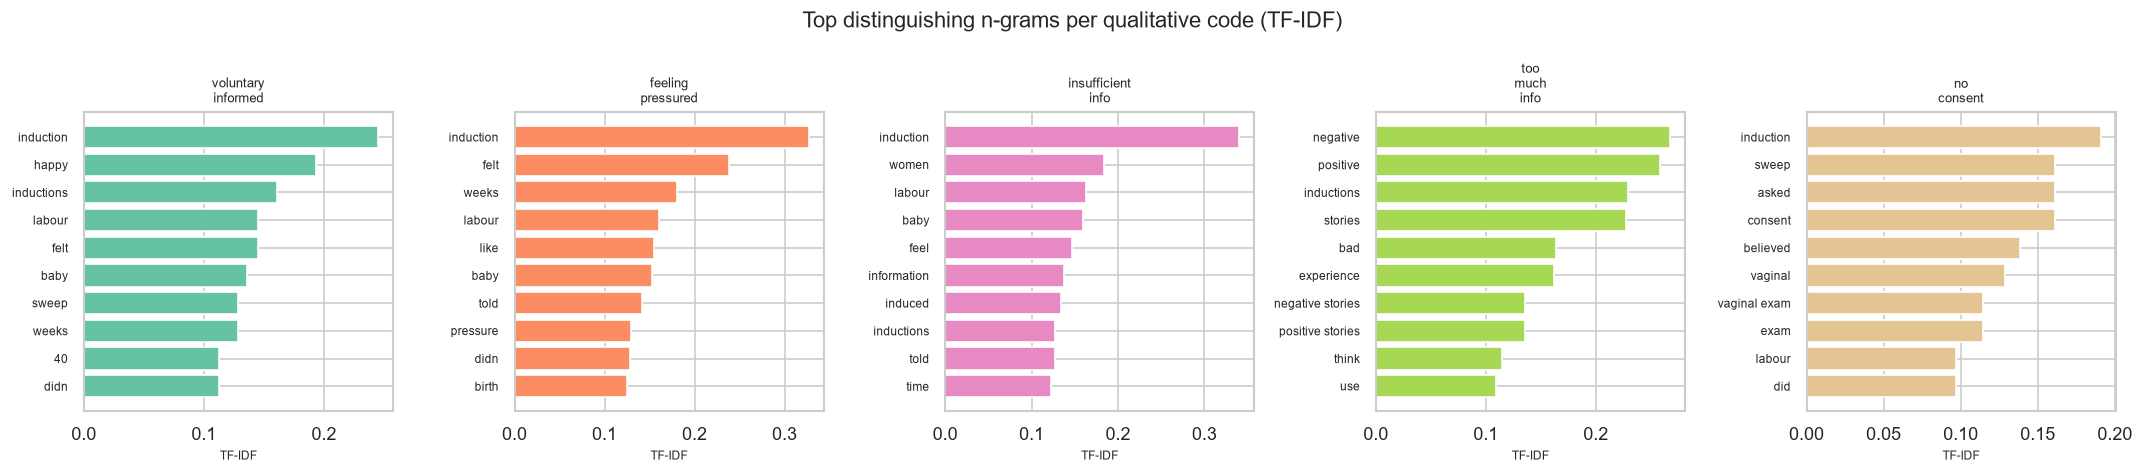

In [10]:
# ── Figure 4: Top distinguishing bigrams per code (c-TF-IDF preview) ──────────
from sklearn.feature_extraction.text import TfidfVectorizer

fig, axes = plt.subplots(1, len(DECISION_CODES), figsize=(18, 4))

# Compute TF-IDF per class (pseudo c-TF-IDF by treating each class as a document)
class_docs = {}
for code in DECISION_CODES:
    texts = dm_df[dm_df['code'] == code]['response_text'].tolist()
    class_docs[code] = ' '.join(texts)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english',
                              max_features=5000, min_df=1)
tfidf_mat  = vectorizer.fit_transform(list(class_docs.values()))
feature_names = vectorizer.get_feature_names_out()

for i, (code, ax) in enumerate(zip(DECISION_CODES.keys(), axes)):
    row      = tfidf_mat[i].toarray().flatten()
    top_idx  = row.argsort()[::-1][:10]
    top_words  = [feature_names[j] for j in top_idx]
    top_scores = [row[j] for j in top_idx]
    ax.barh(top_words[::-1], top_scores[::-1], color=plt.cm.Set2(i/5))
    ax.set_title(code.replace('_', '\n'), fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xlabel('TF-IDF', fontsize=7)

plt.suptitle('Top distinguishing n-grams per qualitative code (TF-IDF)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tfidf_ngrams.png', bbox_inches='tight')
plt.show()

## 5. Save processed data for downstream notebooks

In [ ]:
import hashlib
import json
import pickle
from datetime import datetime, timezone

ID_COLS = ['response_id', 'source_row_id']
if dm_df['response_id'].duplicated().any():
    raise ValueError('response_id must be unique before export')
if dm_df['source_row_id'].isna().any():
    raise ValueError('source_row_id must be complete before export')

dm_path = DATA_DIR / 'decision_making.csv'
exp_path = DATA_DIR / 'experience.csv'
full_path = DATA_DIR / 'full.csv'
dm_df.to_csv(dm_path, index=False)
exp_df.to_csv(exp_path, index=False)
data['full'].to_csv(full_path, index=False)

fingerprint_cols = [c for c in ['response_id', 'source_row_id', 'response_text', 'label'] if c in dm_df]
fingerprint_payload = dm_df[fingerprint_cols].sort_values('response_id').to_csv(index=False).encode('utf-8')
manifest = {
    'artifact_role': 'immutable cleaned response-level base table',
    'created_utc': datetime.now(timezone.utc).isoformat(),
    'rows': int(len(dm_df)),
    'unique_response_ids': int(dm_df['response_id'].nunique()),
    'fingerprint_columns': fingerprint_cols,
    'sha256': hashlib.sha256(fingerprint_payload).hexdigest(),
    'downstream_join_key': 'response_id',
    'rule': 'Notebooks 01 onward must not overwrite decision_making.csv.',
}
(DATA_DIR / 'decision_making_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')

config = {
    'DECISION_CODES': DECISION_CODES,
    'EXPERIENCE_CODES': EXPERIENCE_CODES,
    'CODE_DEFINITIONS': CODE_DEFINITIONS,
    'DEVICE': DEVICE,
    'SEED': SEED,
    'DECISION_DATA_SHA256': manifest['sha256'],
}
with open(DATA_DIR / 'config.pkl', 'wb') as f:
    pickle.dump(config, f)

print(f'Saved immutable base: {dm_path} ({len(dm_df)} rows)')
print(f'Saved fingerprint: {DATA_DIR / "decision_making_manifest.json"}')
print('Traceability: response_id and source_row_id retained; downstream outputs must join by response_id.')
